# 🔍 Semana 5 - Dia 1: Fundamentos de Clustering

**Objetivo:** Aprender K-Means e Clustering Hierárquico na prática  
**Dataset:** Mall Customers (segmentação de clientes)  
**Doc teórico:** [20-dia1-semana5-clustering-fundamentos.md](../../docs/20-dia1-semana5-clustering-fundamentos.md)

---

## 📋 Roteiro

1. Setup e carregamento dos dados
2. EDA rápida
3. Pré-processamento (escalar!)
4. K-Means: Elbow Method
5. K-Means: Silhouette Score
6. K-Means: Treinar e visualizar clusters
7. Clustering Hierárquico: Dendrograma
8. Clustering Hierárquico: Treinar e comparar
9. Interpretação dos clusters
10. Resumo e próximos passos

## 1. Setup e Imports

In [1]:
# Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score, silhouette_samples
from scipy.cluster.hierarchy import dendrogram, linkage
import warnings
warnings.filterwarnings('ignore')

# Estilo
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('deep')
print('✅ Imports carregados!')

✅ Imports carregados!


## 2. Carregar Dataset: Mall Customers

Dataset clássico de segmentação de clientes de um shopping.  
**200 clientes** com: gênero, idade, renda anual e score de gastos (1-100).

> Este é um dos datasets mais usados para aprender clustering porque tem clusters naturais bem definidos.

In [2]:
# Criar o dataset Mall Customers (embutido para não depender de download)
# Fonte original: Kaggle - Mall Customer Segmentation Data
np.random.seed(42)

# Grupo 1: Renda alta, gastos altos (clientes premium)
g1_income = np.random.normal(85, 10, 40).clip(60, 137)
g1_spending = np.random.normal(80, 10, 40).clip(60, 99)

# Grupo 2: Renda alta, gastos baixos (econômicos)
g2_income = np.random.normal(85, 10, 40).clip(60, 137)
g2_spending = np.random.normal(20, 8, 40).clip(1, 39)

# Grupo 3: Renda baixa, gastos altos (gastadores)
g3_income = np.random.normal(25, 8, 35).clip(15, 39)
g3_spending = np.random.normal(75, 10, 35).clip(55, 99)

# Grupo 4: Renda baixa, gastos baixos (conservadores)
g4_income = np.random.normal(25, 8, 35).clip(15, 39)
g4_spending = np.random.normal(20, 8, 35).clip(1, 39)

# Grupo 5: Renda média, gastos médios (classe média)
g5_income = np.random.normal(55, 12, 50).clip(35, 75)
g5_spending = np.random.normal(50, 10, 50).clip(35, 65)

# Montar DataFrame
income = np.concatenate([g1_income, g2_income, g3_income, g4_income, g5_income])
spending = np.concatenate([g1_spending, g2_spending, g3_spending, g4_spending, g5_spending])
age = np.random.randint(18, 70, len(income))
gender = np.random.choice(['Male', 'Female'], len(income))

df = pd.DataFrame({
    'CustomerID': range(1, len(income) + 1),
    'Gender': gender,
    'Age': age,
    'Annual_Income_k': np.round(income, 0).astype(int),
    'Spending_Score': np.round(spending, 0).astype(int)
})

print(f'📊 Dataset: {df.shape[0]} clientes, {df.shape[1]} colunas')
df.head(10)

📊 Dataset: 200 clientes, 5 colunas


,CustomerID,Gender,Age,Annual_Income_k,Spending_Score
0,1,Male,52,90,87
1,2,Female,18,84,82
2,3,Male,38,91,79
3,4,Female,65,100,77
4,5,Male,23,83,65
5,6,Female,45,83,73
6,7,Female,34,101,75
7,8,Male,22,93,91
8,9,Female,48,80,83
9,10,Female,22,90,62


## 3. EDA Rápida

Antes de agrupar, precisamos **entender os dados**.

In [3]:
# Estatísticas descritivas
print('📊 Estatísticas Descritivas:')
print('=' * 50)
df.describe().round(1)

📊 Estatísticas Descritivas:


,CustomerID,Age,Annual_Income_k,Spending_Score
count,200.0,200.0,200.0,200.0
mean,100.5,42.8,56.2,49.8
std,57.9,15.4,26.8,26.8
min,1.0,18.0,15.0,4.0
25%,50.8,30.8,30.0,23.8
50%,100.5,42.5,58.0,51.5
75%,150.2,55.2,81.2,75.2
max,200.0,69.0,110.0,99.0


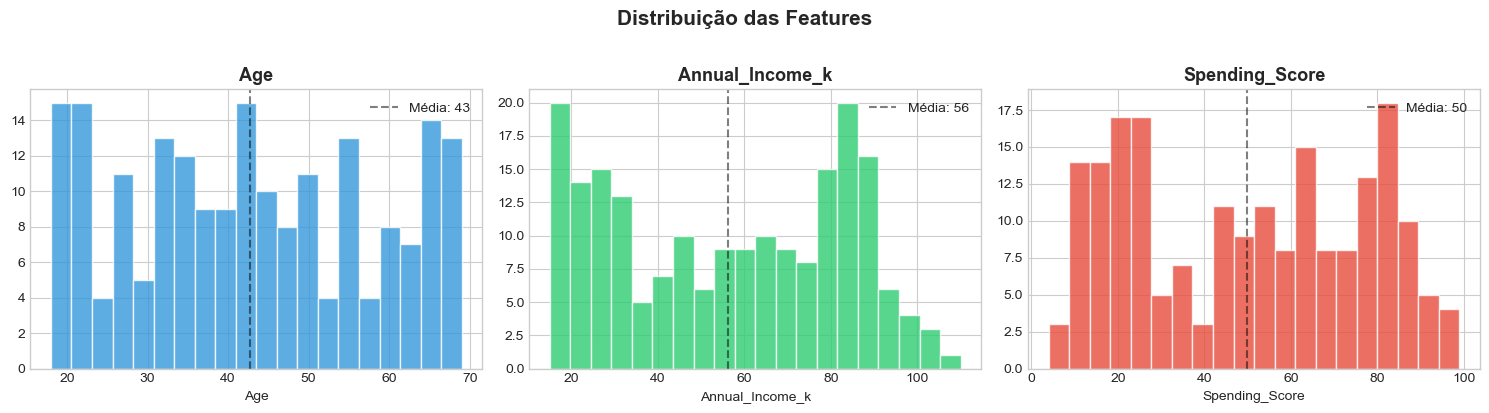

In [4]:
# Distribuições
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, col, color in zip(axes, ['Age', 'Annual_Income_k', 'Spending_Score'], 
                           ['#3498db', '#2ecc71', '#e74c3c']):
    ax.hist(df[col], bins=20, color=color, edgecolor='white', alpha=0.8)
    ax.set_title(col, fontsize=13, fontweight='bold')
    ax.set_xlabel(col)
    ax.axvline(df[col].mean(), color='black', linestyle='--', alpha=0.5, label=f'Média: {df[col].mean():.0f}')
    ax.legend()

plt.suptitle('Distribuição das Features', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

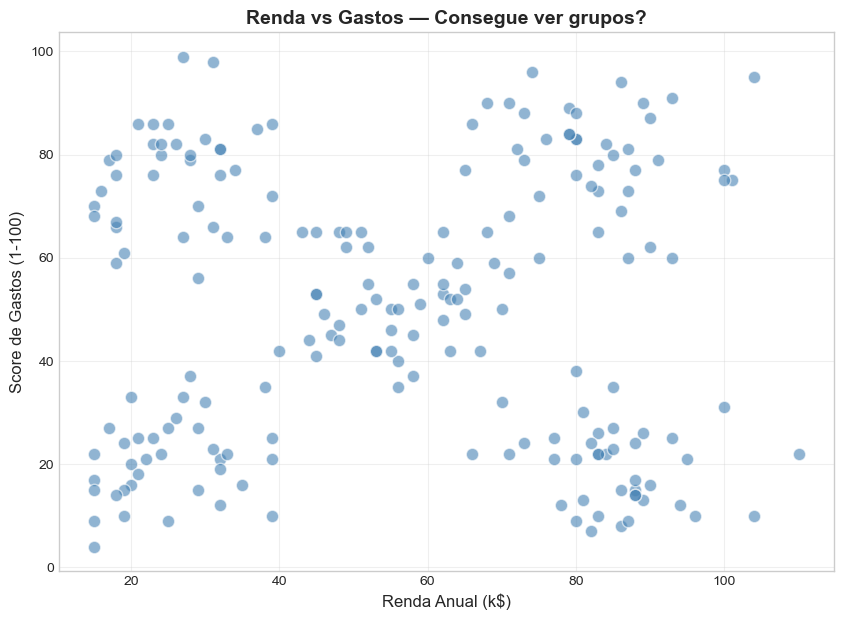

👆 Olhe o gráfico: você consegue identificar grupos naturais a olho nu?
   Vamos ver se o algoritmo encontra os mesmos padrões que você!


In [5]:
# Scatter plot: Renda vs Score de Gastos
# 🔍 Este é o plot mais revelador - já dá pra ver grupos naturais?

plt.figure(figsize=(10, 7))
plt.scatter(df['Annual_Income_k'], df['Spending_Score'], 
            c='steelblue', alpha=0.6, edgecolors='white', s=80)
plt.xlabel('Renda Anual (k$)', fontsize=12)
plt.ylabel('Score de Gastos (1-100)', fontsize=12)
plt.title('Renda vs Gastos — Consegue ver grupos?', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.show()

print('👆 Olhe o gráfico: você consegue identificar grupos naturais a olho nu?')
print('   Vamos ver se o algoritmo encontra os mesmos padrões que você!')

## 4. Pré-processamento

⚠️ **REGRA #1 de Clustering:** Sempre escalar os dados!

Vamos usar apenas `Annual_Income_k` e `Spending_Score` para facilitar a visualização 2D.

In [6]:
# Selecionar features para clustering
X = df[['Annual_Income_k', 'Spending_Score']].values

# Escalar
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f'Shape: {X_scaled.shape}')
print(f'\nAntes de escalar:')
print(f'  Income - Média: {X[:, 0].mean():.1f}, Std: {X[:, 0].std():.1f}')
print(f'  Score  - Média: {X[:, 1].mean():.1f}, Std: {X[:, 1].std():.1f}')
print(f'\nDepois de escalar:')
print(f'  Income - Média: {X_scaled[:, 0].mean():.4f}, Std: {X_scaled[:, 0].std():.4f}')
print(f'  Score  - Média: {X_scaled[:, 1].mean():.4f}, Std: {X_scaled[:, 1].std():.4f}')
print(f'\n✅ Ambas as features agora têm média ~0 e desvio ~1')

Shape: (200, 2)

Antes de escalar:
  Income - Média: 56.2, Std: 26.7
  Score  - Média: 49.8, Std: 26.7

Depois de escalar:
  Income - Média: 0.0000, Std: 1.0000
  Score  - Média: -0.0000, Std: 1.0000

✅ Ambas as features agora têm média ~0 e desvio ~1


## 5. K-Means: Encontrando o Melhor K

### 5.1 Método do Cotovelo (Elbow Method)

Procuramos o ponto onde a **inércia para de cair significativamente**.

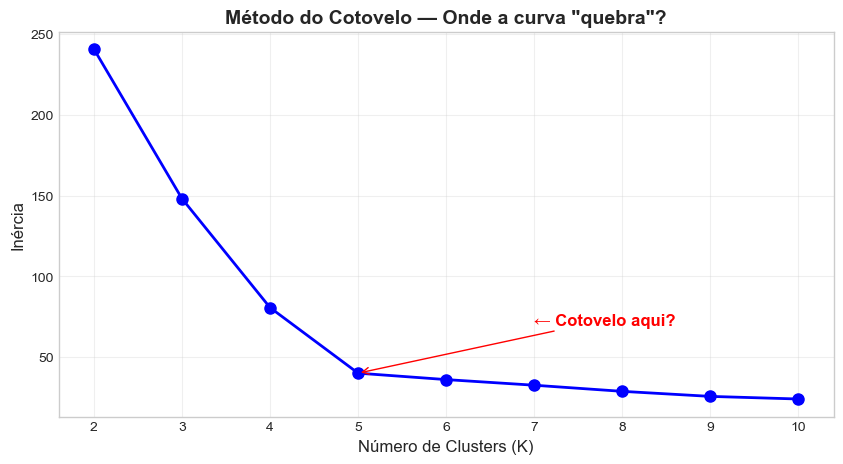


📊 Inércia por K:
  K=2: 240.8
  K=3: 148.2 (↓92.6)
  K=4: 80.7 (↓67.5)
  K=5: 40.1 (↓40.6)
  K=6: 36.1 (↓4.0)
  K=7: 32.6 (↓3.5)
  K=8: 28.8 (↓3.8)
  K=9: 25.7 (↓3.1)
  K=10: 24.1 (↓1.6)


In [7]:
# Elbow Method
K_range = range(2, 11)
inertias = []

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)

# Plot
plt.figure(figsize=(10, 5))
plt.plot(K_range, inertias, 'bo-', linewidth=2, markersize=8)
plt.xlabel('Número de Clusters (K)', fontsize=12)
plt.ylabel('Inércia', fontsize=12)
plt.title('Método do Cotovelo — Onde a curva "quebra"?', fontsize=14, fontweight='bold')
plt.xticks(K_range)
plt.grid(True, alpha=0.3)

# Marcar o cotovelo provável
plt.annotate('← Cotovelo aqui?', xy=(5, inertias[3]), fontsize=12,
             xytext=(7, inertias[3] + 30),
             arrowprops=dict(arrowstyle='->', color='red'),
             color='red', fontweight='bold')
plt.show()

print('\n📊 Inércia por K:')
for k, inertia in zip(K_range, inertias):
    drop = '' if k == 2 else f' (↓{inertias[k-3] - inertia:.1f})'
    print(f'  K={k}: {inertia:.1f}{drop}')

### 5.2 Silhouette Score

Confirma a escolha do K com uma **métrica de qualidade**.

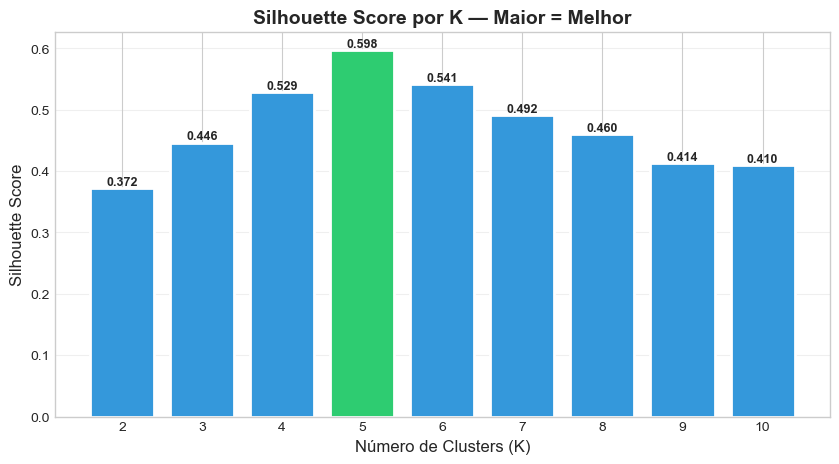


🏆 Melhor K pelo Silhouette Score: K=5 (score=0.598)


In [8]:
# Silhouette Score para cada K
sil_scores = []

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    sil_scores.append(score)

# Plot
plt.figure(figsize=(10, 5))
colors = ['#2ecc71' if s == max(sil_scores) else '#3498db' for s in sil_scores]
bars = plt.bar(K_range, sil_scores, color=colors, edgecolor='white', linewidth=2)
plt.xlabel('Número de Clusters (K)', fontsize=12)
plt.ylabel('Silhouette Score', fontsize=12)
plt.title('Silhouette Score por K — Maior = Melhor', fontsize=14, fontweight='bold')
plt.xticks(K_range)
plt.grid(True, alpha=0.3, axis='y')

# Anotar valores
for bar, score in zip(bars, sil_scores):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
             f'{score:.3f}', ha='center', fontsize=9, fontweight='bold')

plt.show()

best_k = list(K_range)[np.argmax(sil_scores)]
print(f'\n🏆 Melhor K pelo Silhouette Score: K={best_k} (score={max(sil_scores):.3f})')

## 6. K-Means: Treinar e Visualizar

Vamos treinar com o melhor K e visualizar os clusters.

In [9]:
# Treinar K-Means com o melhor K
kmeans_final = KMeans(n_clusters=best_k, random_state=42, n_init=10)
df['KMeans_Cluster'] = kmeans_final.fit_predict(X_scaled)

# Centróides (de volta à escala original)
centroids_original = scaler.inverse_transform(kmeans_final.cluster_centers_)

print(f'✅ K-Means treinado com K={best_k}')
print(f'\n📍 Centróides (escala original):')
for i, (inc, sco) in enumerate(centroids_original):
    n_points = (df['KMeans_Cluster'] == i).sum()
    print(f'  Cluster {i}: Renda={inc:.0f}k, Score={sco:.0f} ({n_points} clientes)')

✅ K-Means treinado com K=5

📍 Centróides (escala original):
  Cluster 0: Renda=85k, Score=20 (40 clientes)
  Cluster 1: Renda=26k, Score=76 (36 clientes)
  Cluster 2: Renda=83k, Score=80 (40 clientes)
  Cluster 3: Renda=25k, Score=21 (36 clientes)
  Cluster 4: Renda=56k, Score=52 (48 clientes)


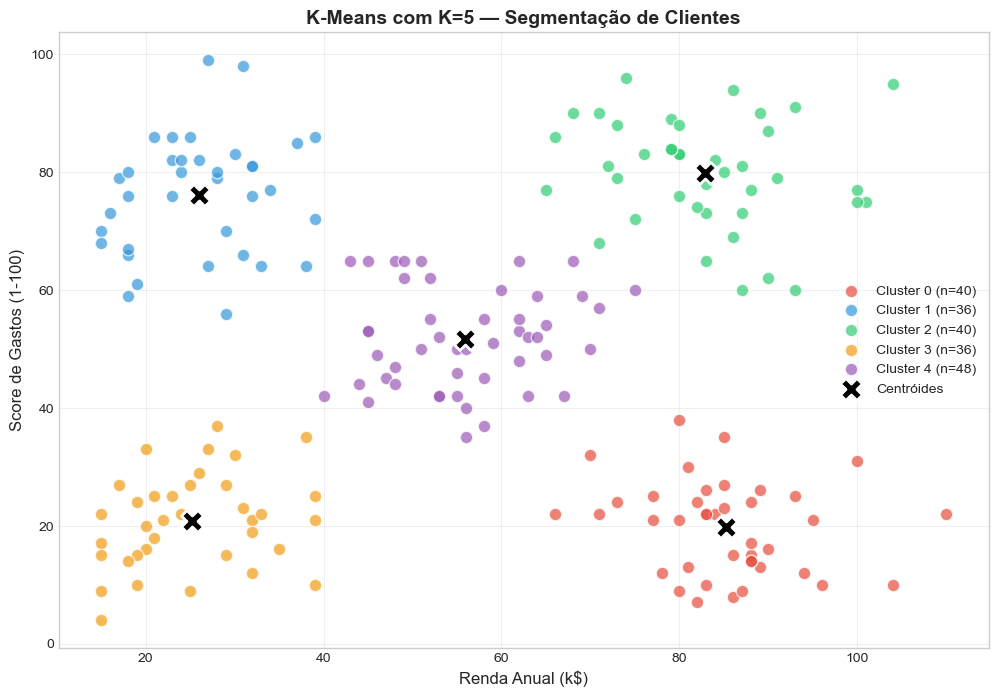


🎯 Compare com o scatter plot sem cores do início!
   O algoritmo encontrou os mesmos padrões que você viu a olho nu?


In [10]:
# Visualizar clusters K-Means
plt.figure(figsize=(12, 8))

colors_map = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12', '#9b59b6', '#1abc9c']
cluster_names = [f'Cluster {i}' for i in range(best_k)]

for i in range(best_k):
    mask = df['KMeans_Cluster'] == i
    plt.scatter(df.loc[mask, 'Annual_Income_k'], df.loc[mask, 'Spending_Score'],
                c=colors_map[i], label=f'Cluster {i} (n={mask.sum()})',
                alpha=0.7, edgecolors='white', s=80)

# Plotar centróides
plt.scatter(centroids_original[:, 0], centroids_original[:, 1],
            c='black', marker='X', s=250, linewidths=2, edgecolors='white',
            label='Centróides', zorder=5)

plt.xlabel('Renda Anual (k$)', fontsize=12)
plt.ylabel('Score de Gastos (1-100)', fontsize=12)
plt.title(f'K-Means com K={best_k} — Segmentação de Clientes', fontsize=14, fontweight='bold')
plt.legend(fontsize=10, loc='best')
plt.grid(True, alpha=0.3)
plt.show()

print('\n🎯 Compare com o scatter plot sem cores do início!')
print('   O algoritmo encontrou os mesmos padrões que você viu a olho nu?')

## 7. Clustering Hierárquico: Dendrograma

O dendrograma nos permite **visualizar a hierarquia** de agrupamentos e escolher K **depois**.

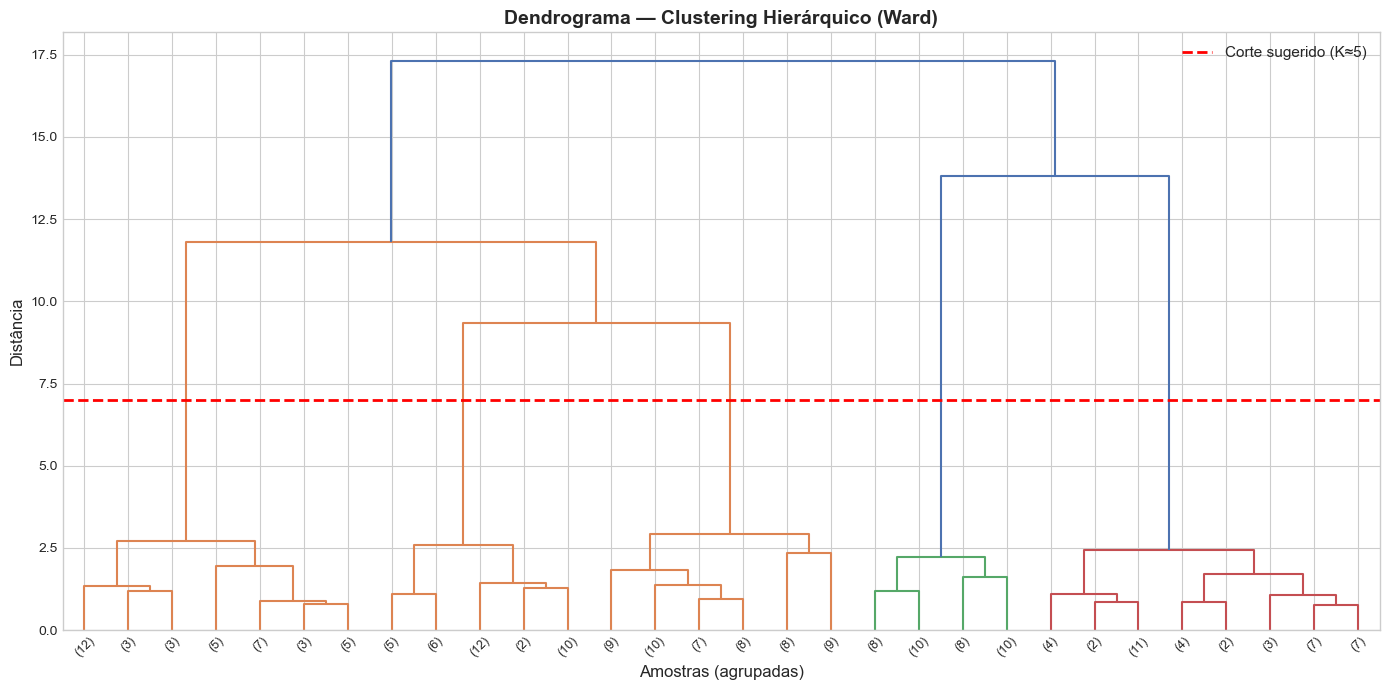

🔍 O dendrograma mostra como os clusters se fundem hierarquicamente.
   A linha vermelha sugere onde "cortar" para obter ~5 clusters.
   Branches que se juntam em alturas altas = grupos muito diferentes.


In [11]:
# Calcular linkage (Ward = minimiza variância)
Z = linkage(X_scaled, method='ward')

# Plotar dendrograma completo
plt.figure(figsize=(14, 7))
dendrogram(Z, truncate_mode='lastp', p=30,
           leaf_font_size=9, show_leaf_counts=True)
plt.title('Dendrograma — Clustering Hierárquico (Ward)', fontsize=14, fontweight='bold')
plt.xlabel('Amostras (agrupadas)', fontsize=12)
plt.ylabel('Distância', fontsize=12)

# Linha de corte para K=5
plt.axhline(y=7, color='red', linestyle='--', linewidth=2, label='Corte sugerido (K≈5)')
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

print('🔍 O dendrograma mostra como os clusters se fundem hierarquicamente.')
print('   A linha vermelha sugere onde "cortar" para obter ~5 clusters.')
print('   Branches que se juntam em alturas altas = grupos muito diferentes.')

## 8. Clustering Hierárquico: Treinar e Comparar

In [12]:
# Treinar Clustering Hierárquico com mesmo K
agg = AgglomerativeClustering(n_clusters=best_k, linkage='ward')
df['Hierarquico_Cluster'] = agg.fit_predict(X_scaled)

# Silhouette do hierárquico
sil_hier = silhouette_score(X_scaled, df['Hierarquico_Cluster'])
sil_km = silhouette_score(X_scaled, df['KMeans_Cluster'])

print(f'📊 Comparação de Silhouette Score (K={best_k}):')
print(f'  K-Means:     {sil_km:.4f}')
print(f'  Hierárquico: {sil_hier:.4f}')
print(f'\n  Melhor: {"K-Means" if sil_km >= sil_hier else "Hierárquico"} ✅')

📊 Comparação de Silhouette Score (K=5):
  K-Means:     0.5978
  Hierárquico: 0.5896

  Melhor: K-Means ✅


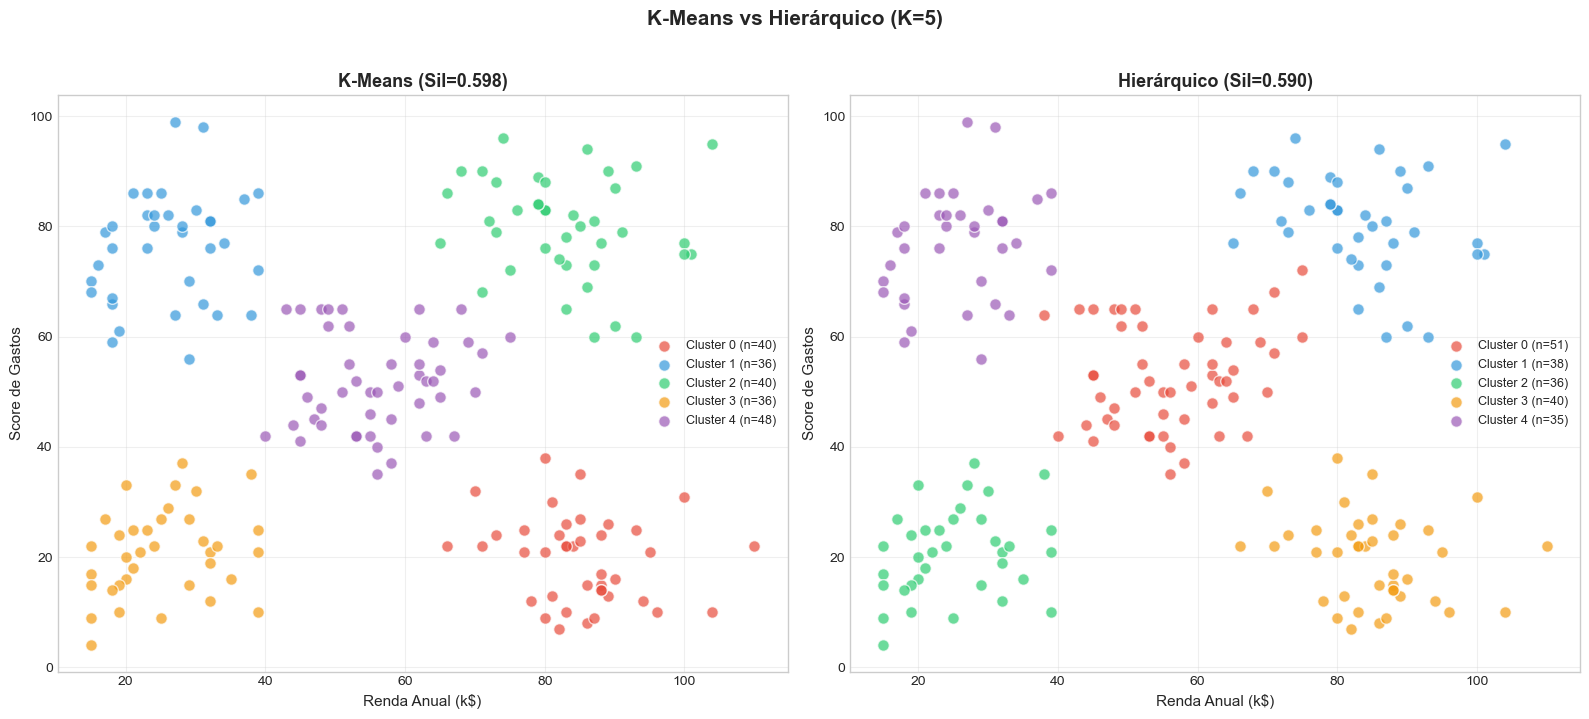


🤝 Adjusted Rand Index (concordância): 0.960
   (1.0 = idênticos, 0.0 = aleatório)


In [13]:
# Comparar visualmente: K-Means vs Hierárquico
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

for ax, col, title in zip(axes, ['KMeans_Cluster', 'Hierarquico_Cluster'],
                           [f'K-Means (Sil={sil_km:.3f})', f'Hierárquico (Sil={sil_hier:.3f})']):
    for i in range(best_k):
        mask = df[col] == i
        ax.scatter(df.loc[mask, 'Annual_Income_k'], df.loc[mask, 'Spending_Score'],
                   c=colors_map[i], alpha=0.7, edgecolors='white', s=70,
                   label=f'Cluster {i} (n={mask.sum()})')
    ax.set_xlabel('Renda Anual (k$)', fontsize=11)
    ax.set_ylabel('Score de Gastos', fontsize=11)
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

plt.suptitle(f'K-Means vs Hierárquico (K={best_k})', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Concordância entre os dois métodos
from sklearn.metrics import adjusted_rand_score
ari = adjusted_rand_score(df['KMeans_Cluster'], df['Hierarquico_Cluster'])
print(f'\n🤝 Adjusted Rand Index (concordância): {ari:.3f}')
print(f'   (1.0 = idênticos, 0.0 = aleatório)')

## 9. Interpretação dos Clusters

Clustering sem interpretação é inútil. Vamos dar **significado** a cada grupo.

In [14]:
# Perfil de cada cluster (usando K-Means)
print('📊 Perfil dos Clusters (K-Means):')
print('=' * 60)

cluster_profiles = df.groupby('KMeans_Cluster').agg({
    'Annual_Income_k': ['mean', 'std', 'count'],
    'Spending_Score': ['mean', 'std'],
    'Age': ['mean']
}).round(1)

cluster_profiles.columns = ['Renda_Média', 'Renda_Std', 'N_Clientes', 
                             'Score_Médio', 'Score_Std', 'Idade_Média']
cluster_profiles

📊 Perfil dos Clusters (K-Means):


,Renda_Média,Renda_Std,N_Clientes,Score_Médio,Score_Std,Idade_Média
KMeans_Cluster,,,,,,
0,85.2,8.7,40,19.7,7.8,46.3
1,26.0,7.1,36,76.1,10.1,37.8
2,82.8,9.6,40,79.8,9.3,40.0
3,25.2,7.6,36,20.8,8.0,43.8
4,55.9,8.5,48,51.7,8.5,45.0


In [15]:
# Dar nomes significativos aos clusters
# (baseado nos centróides - renda e score)

def nomear_cluster(row):
    renda = row['Renda_Média']
    score = row['Score_Médio']
    
    if renda > 70 and score > 60:
        return '💎 Premium (renda alta + gastam muito)'
    elif renda > 70 and score < 40:
        return '💰 Econômicos (renda alta + gastam pouco)'
    elif renda < 40 and score > 55:
        return '🛍️ Gastadores (renda baixa + gastam muito)'
    elif renda < 40 and score < 40:
        return '🏠 Conservadores (renda baixa + gastam pouco)'
    else:
        return '⚖️ Classe Média (renda e gastos moderados)'

cluster_profiles['Perfil'] = cluster_profiles.apply(nomear_cluster, axis=1)

print('🏷️ Perfis Identificados:')
print('=' * 70)
for idx, row in cluster_profiles.iterrows():
    print(f'\n  Cluster {idx}: {row["Perfil"]}')
    print(f'    Renda: {row["Renda_Média"]:.0f}k (±{row["Renda_Std"]:.0f})')
    print(f'    Score: {row["Score_Médio"]:.0f} (±{row["Score_Std"]:.0f})')
    print(f'    Clientes: {row["N_Clientes"]:.0f}')

🏷️ Perfis Identificados:

  Cluster 0: 💰 Econômicos (renda alta + gastam pouco)
    Renda: 85k (±9)
    Score: 20 (±8)
    Clientes: 40

  Cluster 1: 🛍️ Gastadores (renda baixa + gastam muito)
    Renda: 26k (±7)
    Score: 76 (±10)
    Clientes: 36

  Cluster 2: 💎 Premium (renda alta + gastam muito)
    Renda: 83k (±10)
    Score: 80 (±9)
    Clientes: 40

  Cluster 3: 🏠 Conservadores (renda baixa + gastam pouco)
    Renda: 25k (±8)
    Score: 21 (±8)
    Clientes: 36

  Cluster 4: ⚖️ Classe Média (renda e gastos moderados)
    Renda: 56k (±8)
    Score: 52 (±8)
    Clientes: 48


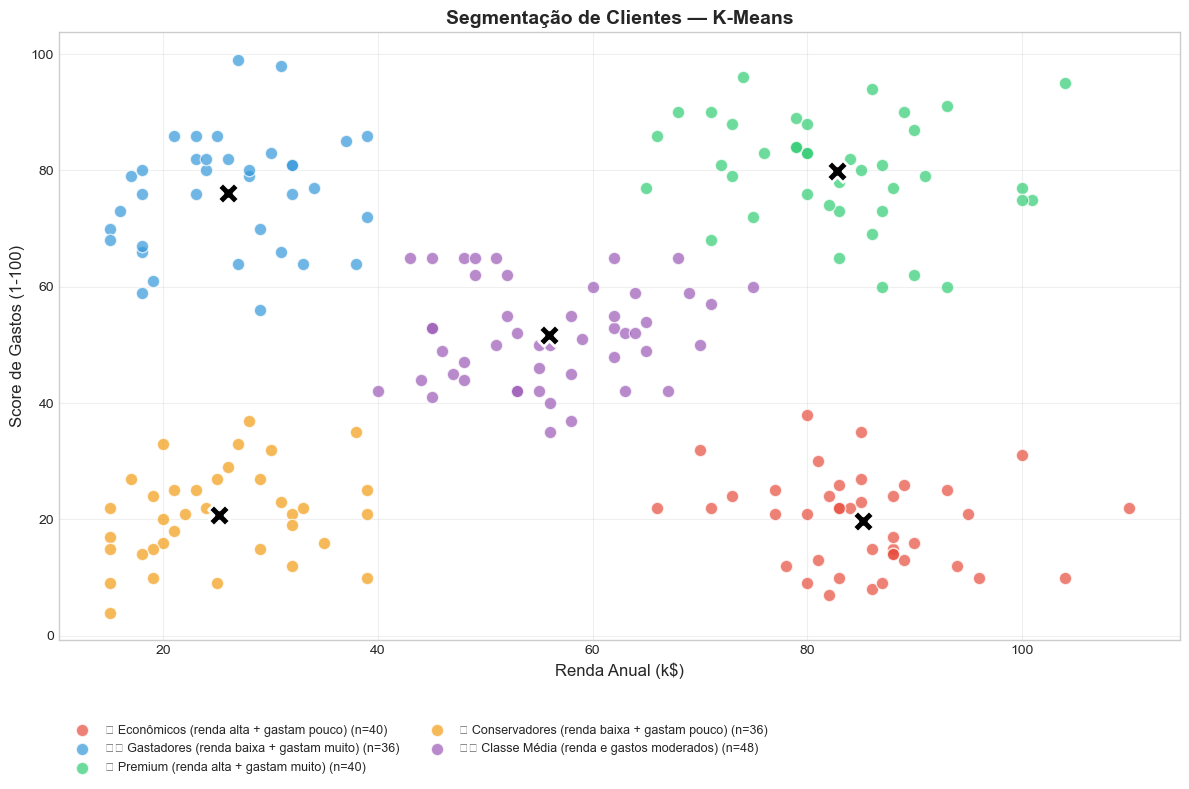

In [16]:
# Visualização final: clusters com nomes
plt.figure(figsize=(12, 8))

for i in range(best_k):
    mask = df['KMeans_Cluster'] == i
    label = cluster_profiles.loc[i, 'Perfil']
    plt.scatter(df.loc[mask, 'Annual_Income_k'], df.loc[mask, 'Spending_Score'],
                c=colors_map[i], alpha=0.7, edgecolors='white', s=80,
                label=f'{label} (n={mask.sum()})')

# Centróides
plt.scatter(centroids_original[:, 0], centroids_original[:, 1],
            c='black', marker='X', s=250, linewidths=2, edgecolors='white', zorder=5)

plt.xlabel('Renda Anual (k$)', fontsize=12)
plt.ylabel('Score de Gastos (1-100)', fontsize=12)
plt.title('Segmentação de Clientes — K-Means', fontsize=14, fontweight='bold')
plt.legend(fontsize=9, loc='upper left', bbox_to_anchor=(0, -0.12), ncol=2)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 10. Silhouette Plot Detalhado

Mostra a qualidade de **cada ponto** individualmente.

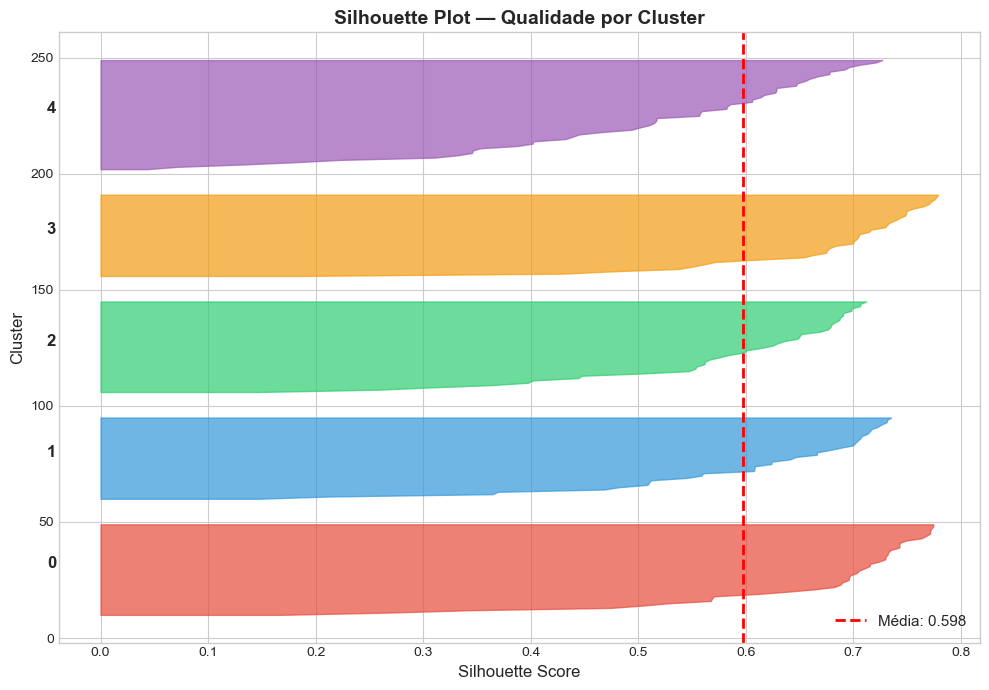

📖 Como ler este gráfico:
  - Barras largas e uniformes = cluster bem formado
  - Barras finas ou com valores negativos = pontos mal classificados
  - A linha vermelha = média geral (quanto mais à direita, melhor)


In [17]:
# Silhouette plot por cluster
labels_km = df['KMeans_Cluster'].values
sample_silhouette = silhouette_samples(X_scaled, labels_km)

fig, ax = plt.subplots(figsize=(10, 7))
y_lower = 10

for i in range(best_k):
    ith_silhouette = sample_silhouette[labels_km == i]
    ith_silhouette.sort()
    size_cluster_i = ith_silhouette.shape[0]
    y_upper = y_lower + size_cluster_i
    
    ax.fill_betweenx(np.arange(y_lower, y_upper), 0, ith_silhouette, 
                     alpha=0.7, color=colors_map[i])
    ax.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i), fontsize=12, fontweight='bold')
    y_lower = y_upper + 10

avg_score = silhouette_score(X_scaled, labels_km)
ax.axvline(x=avg_score, color='red', linestyle='--', linewidth=2, label=f'Média: {avg_score:.3f}')
ax.set_xlabel('Silhouette Score', fontsize=12)
ax.set_ylabel('Cluster', fontsize=12)
ax.set_title('Silhouette Plot — Qualidade por Cluster', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()

print('📖 Como ler este gráfico:')
print('  - Barras largas e uniformes = cluster bem formado')
print('  - Barras finas ou com valores negativos = pontos mal classificados')
print('  - A linha vermelha = média geral (quanto mais à direita, melhor)')

## 11. Resumo e Próximos Passos

### O que Aprendemos Hoje

| Conceito | Status |
|----------|--------|
| Supervisionado vs Não Supervisionado | ✅ |
| K-Means (centróides, inércia) | ✅ |
| Elbow Method | ✅ |
| Silhouette Score | ✅ |
| Clustering Hierárquico (dendrograma) | ✅ |
| Comparação K-Means vs Hierárquico | ✅ |
| Interpretação de clusters | ✅ |

In [18]:
# Resumo final
print('=' * 60)
print('📊 RESUMO — Dia 1: Fundamentos de Clustering')
print('=' * 60)
print(f'\n  Dataset: {df.shape[0]} clientes, 2 features de clustering')
print(f'  Melhor K: {best_k} (Elbow + Silhouette)')
print(f'  K-Means Silhouette:     {sil_km:.4f}')
print(f'  Hierárquico Silhouette: {sil_hier:.4f}')
print(f'  Concordância (ARI):     {ari:.4f}')
print(f'\n  Clusters identificados:')
for idx, row in cluster_profiles.iterrows():
    print(f'    {idx}: {row["Perfil"]} ({row["N_Clientes"]:.0f} clientes)')
print(f'\n✅ Dia 1 concluído!')
print(f'\n📌 Próximo: Dia 2 — DBSCAN + Detecção de Anomalias')
print(f'   Vamos aprender clustering baseado em DENSIDADE')
print(f'   e detectar outliers automaticamente!')

📊 RESUMO — Dia 1: Fundamentos de Clustering

  Dataset: 200 clientes, 2 features de clustering
  Melhor K: 5 (Elbow + Silhouette)
  K-Means Silhouette:     0.5978
  Hierárquico Silhouette: 0.5896
  Concordância (ARI):     0.9595

  Clusters identificados:
    0: 💰 Econômicos (renda alta + gastam pouco) (40 clientes)
    1: 🛍️ Gastadores (renda baixa + gastam muito) (36 clientes)
    2: 💎 Premium (renda alta + gastam muito) (40 clientes)
    3: 🏠 Conservadores (renda baixa + gastam pouco) (36 clientes)
    4: ⚖️ Classe Média (renda e gastos moderados) (48 clientes)

✅ Dia 1 concluído!

📌 Próximo: Dia 2 — DBSCAN + Detecção de Anomalias
   Vamos aprender clustering baseado em DENSIDADE
   e detectar outliers automaticamente!
